# Trabajo Práctico 2 - Grupo 02

### Modelo RoBERTa-BNE — Entrega N1

Integrantes:

*   Bermudez, Agustin
*   Calderón, Tiago
*   Gonzalez Pautaso, Mateo
*   Moreyra, Santiago
*   Nieves, Maylen

**Modelo:** `PlanTL-GOB-ES/roberta-base-bne`

**Dataset:** Train original (51.000 reseñas, distribución 40/20/40)

**Hiperparámetros:** `lr=2e-05` | `epochs=3` | `max_length=128`

**Justificación:** Baseline de RoBERTa-BNE sobre el dataset original. Permite comparar directamente contra BETO v1 (0.72048) con exactamente las mismas condiciones.

**RoBERTa vs BETO:**
RoBERTa es una versión mejorada de BERT que elimina la tarea de Next Sentence Prediction
(NSP) durante el pre-entrenamiento y usa dynamic masking. `roberta-base-bne` fue
pre-entrenado sobre un corpus de 570GB de texto en español de la Biblioteca Nacional de
España — significativamente más grande y diverso que el corpus de BETO.
En benchmarks de NLP en español, RoBERTa-BNE supera consistentemente a BETO.

## 1. Instalación de dependencias

In [1]:
!pip install transformers==4.44.0
!pip install datasets accelerate scikit-learn spacy sentencepiece tiktoken
!python -m spacy download es_core_news_sm

  Using cached es_core_news_sm-3.8.0-py3-none-any.whl (12.9 MB)
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')


## 2. Imports y configuración

In [2]:
import sys
sys.path.insert(0, "../../..")  # TP2/

import numpy as np
import pandas as pd
import torch
from pathlib import Path
from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)
from sklearn.metrics import f1_score, classification_report, confusion_matrix

from common.data_utils import get_split, SEED
from common.preprocessing import clean_minimal
from common.evaluation import evaluate

np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_NAME  = "xlm-roberta-large"
MAX_LENGTH  = 128
BATCH_SIZE  = 16
NUM_EPOCHS  = 3
LR          = 2e-05
CLASS_NAMES = ["negativa", "neutra", "positiva"]

print(f"Device: {DEVICE}")
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"Modelo: {MODEL_NAME}")
print(f"Config: lr={LR} | epochs={NUM_EPOCHS} | max_length={MAX_LENGTH}")

c:\Users\Valen\Downloads\cdd\.venv312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
GPU: NVIDIA GeForce RTX 3060
VRAM: 12.9 GB
Modelo: xlm-roberta-large
Config: lr=2e-05 | epochs=3 | max_length=128


## 3. Carga de datos

In [3]:
train_df = pd.read_csv("../../../data/train.csv")
test_df  = pd.read_csv("../../../data/test.csv")

print(f"Train: {len(train_df):,} filas")
print(f"Distribucion:\n{train_df['label'].value_counts().sort_index()}")
print(f"\nProporciones:\n{train_df['label'].value_counts(normalize=True).sort_index().round(3)}")

X_train_raw, X_val_raw, y_train, y_val = get_split(train_df)

print("\nAplicando clean_minimal...")
X_train = np.array([clean_minimal(t) for t in X_train_raw])
X_val   = np.array([clean_minimal(t) for t in X_val_raw])
X_test  = np.array([clean_minimal(t) for t in test_df["text"].values])
print(f"Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}")

Train: 51,000 filas
Distribucion:
label
0    20400
1    10200
2    20400
Name: count, dtype: int64

Proporciones:
label
0    0.4
1    0.2
2    0.4
Name: proportion, dtype: float64

Aplicando clean_minimal...
Train: 40,800 | Val: 10,200 | Test: 8,500


## 4. Dataset y tokenización

In [4]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# RoBERTa usa BPE (Byte-Pair Encoding) en vez del WordPiece de BETO.
# El tokenizer es distinto — no hay tokens [CLS]/[SEP] sino <s>/</s>.
# HuggingFace lo maneja automáticamente con from_pretrained.
print("Ejemplo de tokenizacion con RoBERTa-BNE:")
for t in ["No funciona bien, muy decepcionante.", "Excelente producto."]:
    print(f"  '{t}' → {tokenizer.tokenize(t)}")

class ResenasDataset(Dataset):
    def __init__(self, texts, labels=None, tokenizer=None, max_length=128):
        self.encodings = tokenizer(
            list(texts),
            truncation=True,
            padding="max_length",
            max_length=max_length,
            return_tensors="pt",
        )
        self.labels = labels

    def __len__(self):
        return len(self.encodings["input_ids"])

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        if self.labels is not None:
            item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

print("\nTokenizando datasets...")
train_dataset = ResenasDataset(X_train, y_train, tokenizer, MAX_LENGTH)
val_dataset   = ResenasDataset(X_val,   y_val,   tokenizer, MAX_LENGTH)
test_dataset  = ResenasDataset(X_test,  None,    tokenizer, MAX_LENGTH)
print("Listo.")

c:\Users\Valen\Downloads\cdd\.venv312\Lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Ejemplo de tokenizacion con RoBERTa-BNE:
  'No funciona bien, muy decepcionante.' → ['▁No', '▁funciona', '▁bien', ',', '▁muy', '▁decepcion', 'ante', '.']
  'Excelente producto.' → ['▁Excelente', '▁producto', '.']

Tokenizando datasets...
Listo.


## 5. Modelo y métricas

In [5]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    ignore_mismatched_sizes=True,
)
model = model.to(DEVICE)

total_params   = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parametros totales:     {total_params:,}")
print(f"Parametros entrenables: {trainable_params:,}")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    f1_per = f1_score(labels, preds, average=None, zero_division=0)
    return {
        "f1_macro": f1_score(labels, preds, average="macro", zero_division=0),
        "f1_neg":   float(f1_per[0]),
        "f1_neu":   float(f1_per[1]),
        "f1_pos":   float(f1_per[2]),
    }

c:\Users\Valen\Downloads\cdd\.venv312\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Valen\.cache\huggingface\hub\models--xlm-roberta-large. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-

Parametros totales:     559,893,507
Parametros entrenables: 559,893,507


## 6. Fine-tuning

In [6]:
OUTPUT_DIR = Path("models/red_neuronal_roberta_bne_n1_original_51k")

training_args = TrainingArguments(
    output_dir="models/xlm_roberta_large_v1",
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=2,
    learning_rate=LR,
    warmup_ratio=0.1,
    weight_decay=0.01,
    fp16=True,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    logging_steps=100,
    save_total_limit=2,
    report_to="none",
    seed=SEED,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

print(f"Iniciando fine-tuning de RoBERTa-BNE...")
print(f"  Dataset:    original_51k ({len(X_train):,} train)")
print(f"  LR:         {LR}")
print(f"  Epochs:     {NUM_EPOCHS} (early stopping patience=2)")
print(f"  Max length: {MAX_LENGTH}")
trainer.train()

Iniciando fine-tuning de RoBERTa-BNE...
  Dataset:    original_51k (40,800 train)
  LR:         2e-05
  Epochs:     3 (early stopping patience=2)
  Max length: 128


  3%|▎         | 100/3825 [29:14<3:41:56,  3.57s/it]  

{'loss': 1.076, 'grad_norm': 6.723714351654053, 'learning_rate': 5.013054830287206e-06, 'epoch': 0.08}


  5%|▌         | 200/3825 [57:38<3:39:49,  3.64s/it]   

{'loss': 0.8875, 'grad_norm': 28.14406967163086, 'learning_rate': 1.0130548302872064e-05, 'epoch': 0.16}


...

                                                     
100%|██████████| 3825/3825 [5:29:23<00:00,  3.68s/it]

{'eval_loss': 0.5338987112045288, 'eval_f1_macro': 0.732511525193166, 'eval_f1_neg': 0.8392044092978672, 'eval_f1_neu': 0.477853048462741, 'eval_f1_pos': 0.8804771178188899, 'eval_runtime': 73.2341, 'eval_samples_per_second': 139.279, 'eval_steps_per_second': 8.712, 'epoch': 3.0}


100%|██████████| 3825/3825 [5:30:18<00:00,  5.18s/it]

{'train_runtime': 19818.4518, 'train_samples_per_second': 6.176, 'train_steps_per_second': 0.193, 'train_loss': 0.5403682524238537, 'epoch': 3.0}


TrainOutput(global_step=3825, training_loss=0.5403682524238537, metrics={'train_runtime': 19818.4518, 'train_samples_per_second': 6.176, 'train_steps_per_second': 0.193, 'total_flos': 2.85171960711168e+16, 'train_loss': 0.5403682524238537, 'epoch': 3.0})

## 7. Evaluación en validación

In [7]:
preds_output = trainer.predict(val_dataset)
y_pred = np.argmax(preds_output.predictions, axis=1)

evaluate("red_neuronal_roberta_bne_n1_original_51k", y_val, y_pred,
         hyperparams={
             "model": MODEL_NAME,
             "epochs": NUM_EPOCHS,
             "lr": LR,
             "max_length": MAX_LENGTH,
             "batch_size": BATCH_SIZE,
             "dataset": "original_51k",
         })

100%|██████████| 638/638 [01:11<00:00,  8.87it/s]



=== red_neuronal_roberta_bne_n1_original_51k ===
Hiperparámetros: {'model': 'xlm-roberta-large', 'epochs': 3, 'lr': 2e-05, 'max_length': 128, 'batch_size': 16, 'dataset': 'original_51k'}

F1-macro:  0.7325
Precision: 0.7351
Recall:    0.7315
Accuracy:  0.7878

              precision    recall  f1-score   support

    negativa     0.8209    0.8583    0.8392      4080
      neutra     0.5100    0.4495    0.4779      2040
    positiva     0.8745    0.8865    0.8805      4080

    accuracy                         0.7878     10200
   macro avg     0.7351    0.7315    0.7325     10200
weighted avg     0.7802    0.7878    0.7834     10200

Matriz de confusión (filas=real, cols=predicho):
          negativa  neutra  positiva
negativa      3502     508        70
neutra         674     917       449
positiva        90     373      3617


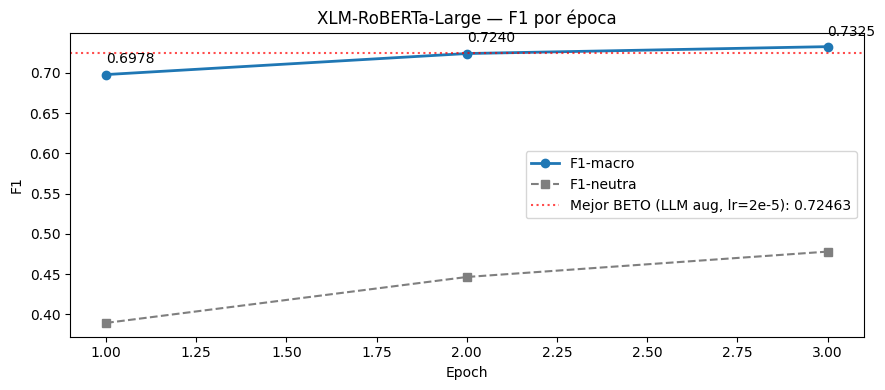

In [10]:
import matplotlib.pyplot as plt

history  = trainer.state.log_history
eval_f1  = [(x["epoch"], x["eval_f1_macro"]) for x in history if "eval_f1_macro" in x]
eval_neu = [(x["epoch"], x["eval_f1_neu"])   for x in history if "eval_f1_neu"   in x]

fig, ax = plt.subplots(figsize=(9, 4))
if eval_f1:
    epochs, f1s = zip(*eval_f1)
    ax.plot(epochs, f1s, marker="o", label="F1-macro", color="#1f77b4", linewidth=2)
    for e, f in zip(epochs, f1s):
        ax.annotate(f"{f:.4f}", (e, f), textcoords="offset points", xytext=(0, 8))
if eval_neu:
    epochs, f1s = zip(*eval_neu)
    ax.plot(epochs, f1s, marker="s", label="F1-neutra", color="#7f7f7f", linestyle="--")

# Referencia: mejor resultado de BETO
ax.axhline(y=0.72463, color="red", linestyle=":", alpha=0.7,
           label="Mejor BETO (LLM aug, lr=2e-5): 0.72463")

ax.set_xlabel("Epoch"); ax.set_ylabel("F1")
ax.set_title(f"XLM-RoBERTa-Large — F1 por época")
ax.legend(); plt.tight_layout(); plt.show()

## 8. Guardado del modelo

In [11]:
SAVE_DIR = Path("models/red_neuronal_roberta_bne_n1_original_51k_final")
trainer.save_model(str(SAVE_DIR))
tokenizer.save_pretrained(str(SAVE_DIR))
print(f"Modelo guardado en {SAVE_DIR}")

Modelo guardado en models\red_neuronal_roberta_bne_n1_original_51k_final


## 9. Submission a Kaggle

In [12]:
Path("submissions").mkdir(exist_ok=True)
preds_test  = trainer.predict(test_dataset)
y_test_pred = np.argmax(preds_test.predictions, axis=1)

sub = pd.DataFrame({"id": test_df["id"].values, "label": y_test_pred.astype(int)})
sub.to_csv("submissions/submission_red_neuronal_roberta_bne_n1_original_51k.csv", index=False)

dist = sub["label"].value_counts(normalize=True).sort_index()
print(f"Guardado: submissions/submission_red_neuronal_roberta_bne_n1_original_51k.csv  ({len(sub)} predicciones)")
print(f"Distribucion: {', '.join(f'clase {k}: {v:.1%}' for k, v in dist.items())}")

100%|██████████| 532/532 [22:08<00:00,  2.50s/it]   

Guardado: submissions/submission_red_neuronal_roberta_bne_n1_original_51k.csv  (8500 predicciones)
Distribucion: clase 0: 42.2%, clase 1: 17.6%, clase 2: 40.2%
